# 난지 주차장 일별 요일 패턴 분석

`Data/한강공원 주차장 일별 이용 현황.csv`를 바탕으로 2022년 1월 1일부터 2025년 12월 31일까지 `난지`가 포함된 주차장을 대상으로 요일 패턴을 분석합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import warnings

warnings.filterwarnings('ignore')

In [2]:
font_candidates = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in available_fonts:
        rcParams['font.family'] = font_name
        break
rcParams['axes.unicode_minus'] = False

In [3]:
file_path = '../Data/한강공원 주차장 일별 이용 현황.csv'
weekday_order = ['월', '화', '수', '목', '금', '토', '일']

df = pd.read_csv(file_path, encoding='cp949')
df['날짜'] = pd.to_datetime(df['날짜'], format='%Y/%m/%d')

nanji_df = (
    df[
        df['주차장명'].astype(str).str.contains('난지', na=False)
        & (df['날짜'] >= '2022-01-01')
        & (df['날짜'] <= '2025-12-31')
    ]
    .sort_values('날짜')
    .reset_index(drop=True)
)

nanji_df.head()

,지구별,주차장명,주차대수,이용시간,날짜
0,PLT-002,"난지1,2,3주차장",1167,53123,2022-01-01
1,PLT-002,"난지1,2,3주차장",939,47775,2022-01-02
2,PLT-002,"난지1,2,3주차장",982,38073,2022-01-03
3,PLT-002,"난지1,2,3주차장",829,32796,2022-01-04
4,PLT-002,"난지1,2,3주차장",858,40224,2022-01-05


## 일별 데이터 준비

같은 날짜에 난지 관련 주차장이 여러 개 있으면 합산하고, 날짜를 요일로 변환합니다.

In [4]:
daily_nanji = (
    nanji_df.groupby('날짜', as_index=False)[['주차대수', '이용시간']]
    .sum()
    .sort_values('날짜')
)

daily_nanji['연도'] = daily_nanji['날짜'].dt.year
daily_nanji['월'] = daily_nanji['날짜'].dt.month
daily_nanji['요일'] = pd.Categorical(
    daily_nanji['날짜'].dt.dayofweek.map(lambda x: weekday_order[x]),
    categories=weekday_order,
    ordered=True
)

print(f'원본 난지 행 수: {len(nanji_df)}')
print(f'일별 분석 행 수: {len(daily_nanji)}')
print(f'분석 기간: {daily_nanji["날짜"].min().date()} ~ {daily_nanji["날짜"].max().date()}')

daily_nanji.head()

원본 난지 행 수: 1455
일별 분석 행 수: 1455
분석 기간: 2022-01-01 ~ 2025-12-31


,날짜,주차대수,이용시간,연도,월,요일
0,2022-01-01,1167,53123,2022,1,토
1,2022-01-02,939,47775,2022,1,일
2,2022-01-03,982,38073,2022,1,월
3,2022-01-04,829,32796,2022,1,화
4,2022-01-05,858,40224,2022,1,수


## 요일별 요약 통계

요일별 평균, 중앙값, 총합, 관측 일수를 통해 기본 패턴을 확인합니다.

In [5]:
weekday_summary = (
    daily_nanji.groupby('요일', observed=False)['주차대수']
    .agg(평균='mean', 중앙값='median', 총합='sum', 관측일수='count')
    .round(1)
    .reindex(weekday_order)
)

weekday_summary

,평균,중앙값,총합,관측일수
요일,,,,
월,1557.6,1565.0,322428,207
화,1509.3,1488.0,315435,209
수,1558.5,1544.0,325724,209
목,1603.3,1599.5,333487,208
금,1728.7,1762.0,359569,208
토,2260.4,2077.0,472420,209
일,2184.9,1999.0,447902,205


## 전체 요일 패턴

2022년부터 2025년까지 전체 기간을 합쳐 요일별 평균 주차대수를 시각화합니다.

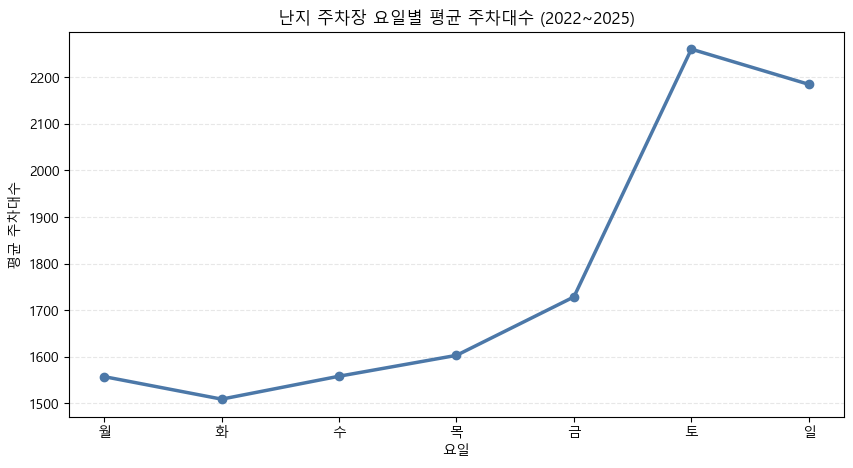

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(
    weekday_summary.index,
    weekday_summary['평균'],
    marker='o',
    linewidth=2.5,
    color='#4C78A8'
)
plt.title('난지 주차장 요일별 평균 주차대수 (2022~2025)')
plt.xlabel('요일')
plt.ylabel('평균 주차대수')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 연도별 요일 패턴 비교

연도별로 요일 평균 주차대수를 계산해 패턴이 해마다 비슷한지 비교합니다.

In [7]:
yearly_weekday = (
    daily_nanji.groupby(['연도', '요일'], observed=False)['주차대수']
    .mean()
    .reset_index()
)

yearly_weekday

,연도,요일,주차대수
0,2022,월,1492.480000
1,2022,화,1408.961538
2,2022,수,1462.942308
3,2022,목,1519.942308
4,2022,금,1696.942308
5,2022,토,2539.490566
6,2022,일,2392.352941
7,2023,월,1564.019231
8,2023,화,1513.153846
9,2023,수,1487.557692


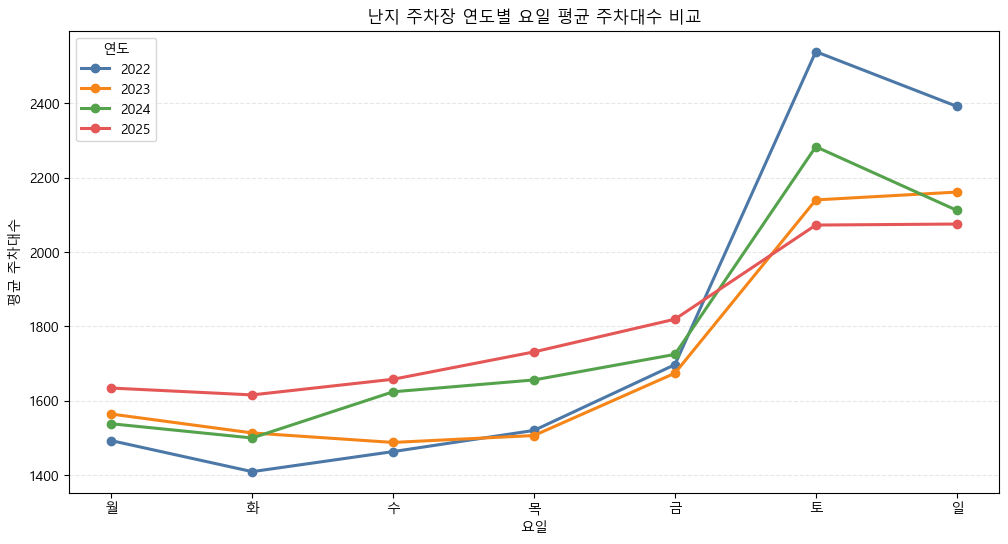

In [8]:
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
years = [2022, 2023, 2024, 2025]

plt.figure(figsize=(12, 6))

for year, color in zip(years, colors):
    year_df = yearly_weekday[yearly_weekday['연도'] == year].copy()
    year_df = year_df.set_index('요일').reindex(weekday_order).reset_index()
    plt.plot(
        year_df['요일'],
        year_df['주차대수'],
        marker='o',
        linewidth=2.2,
        color=color,
        label=str(year)
    )

plt.title('난지 주차장 연도별 요일 평균 주차대수 비교')
plt.xlabel('요일')
plt.ylabel('평균 주차대수')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='연도')
plt.show()

## 패턴 해석

요일 패턴이 얼마나 분명한지 숫자로 간단히 요약합니다.

In [9]:
weekday_mean = weekday_summary['평균']
weekend_mean = weekday_mean[['토', '일']].mean()
weekday_only_mean = weekday_mean[['월', '화', '수', '목', '금']].mean()
peak_day = weekday_mean.idxmax()
low_day = weekday_mean.idxmin()

print(f'가장 이용이 많은 요일: {peak_day}요일 ({weekday_mean[peak_day]:,.1f})')
print(f'가장 이용이 적은 요일: {low_day}요일 ({weekday_mean[low_day]:,.1f})')
print(f'주말 평균 주차대수: {weekend_mean:,.1f}')
print(f'평일 평균 주차대수: {weekday_only_mean:,.1f}')
print(f'주말/평일 배수: {weekend_mean / weekday_only_mean:.2f}배')

가장 이용이 많은 요일: 토요일 (2,260.4)
가장 이용이 적은 요일: 화요일 (1,509.3)
주말 평균 주차대수: 2,222.7
평일 평균 주차대수: 1,591.5
주말/평일 배수: 1.40배


## 월별 패턴 분석

이번에는 일별 데이터를 월 기준으로 묶어, 어느 달에 이용량이 높고 낮은지 확인합니다.

In [10]:
monthly_summary = (
    daily_nanji.groupby('월')['주차대수']
    .agg(평균='mean', 중앙값='median', 총합='sum', 관측일수='count')
    .round(1)
    .reindex(range(1, 13))
)

monthly_summary

,평균,중앙값,총합,관측일수
월,,,,
1,1077.8,1095.0,132573,123
2,1246.5,1287.0,140855,113
3,1568.7,1479.0,194522,124
4,2144.5,1874.5,257343,120
5,2320.1,1963.0,287696,124
6,2039.1,1888.0,240608,118
7,1647.3,1604.5,204260,124
8,1801.0,1737.5,223330,124
9,2511.7,2074.0,301409,120


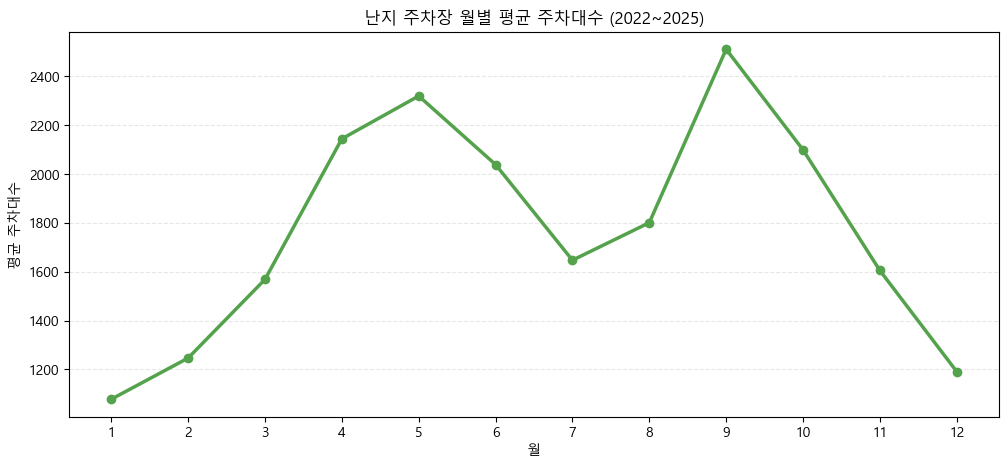

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_summary.index,
    monthly_summary['평균'],
    marker='o',
    linewidth=2.5,
    color='#54A24B'
)
plt.title('난지 주차장 월별 평균 주차대수 (2022~2025)')
plt.xlabel('월')
plt.ylabel('평균 주차대수')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [12]:
yearly_month = (
    daily_nanji.groupby(['연도', '월'], observed=False)['주차대수']
    .mean()
    .reset_index()
)

yearly_month.head()

,연도,월,주차대수
0,2022,1,1127.838710
1,2022,2,1117.178571
2,2022,3,1364.290323
3,2022,4,2186.800000
4,2022,5,2643.677419


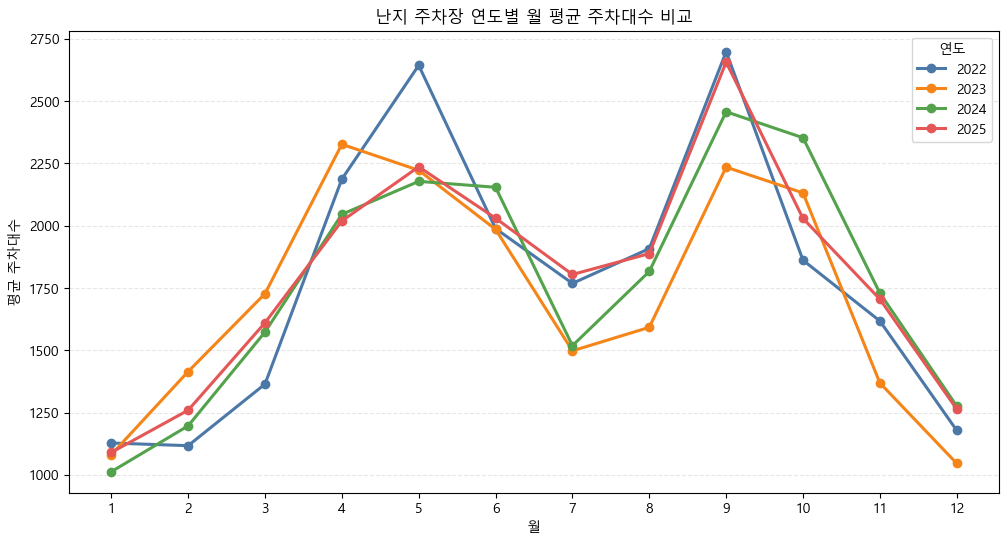

In [13]:
plt.figure(figsize=(12, 6))

for year, color in zip(years, colors):
    year_df = yearly_month[yearly_month['연도'] == year].sort_values('월')
    plt.plot(
        year_df['월'],
        year_df['주차대수'],
        marker='o',
        linewidth=2.2,
        color=color,
        label=str(year)
    )

plt.title('난지 주차장 연도별 월 평균 주차대수 비교')
plt.xlabel('월')
plt.ylabel('평균 주차대수')
plt.xticks(range(1, 13))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='연도')
plt.show()

## 연별 패턴 분석

연도별로 평균과 총합을 비교해 이용 규모가 어떻게 달라졌는지 확인합니다.

In [14]:
yearly_summary = (
    daily_nanji.groupby('연도')['주차대수']
    .agg(평균='mean', 중앙값='median', 총합='sum', 관측일수='count')
    .round(1)
)

yearly_summary

,평균,중앙값,총합,관측일수
연도,,,,
2022,1789.6,1607.0,647844,362
2023,1719.8,1587.0,624270,363
2024,1774.5,1661.0,647690,365
2025,1800.4,1740.0,657161,365


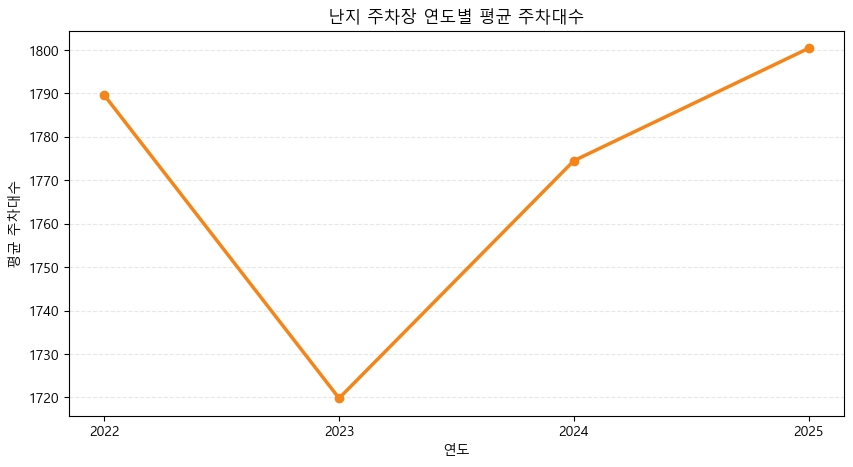

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(
    yearly_summary.index.astype(str),
    yearly_summary['평균'],
    marker='o',
    linewidth=2.5,
    color='#F58518'
)
plt.title('난지 주차장 연도별 평균 주차대수')
plt.xlabel('연도')
plt.ylabel('평균 주차대수')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 공휴일+주말 vs 평일 분석

요일뿐 아니라 한국 공휴일 여부를 함께 반영해 `공휴일+주말`과 `평일`로 나눠 비교합니다.

아래 공휴일 목록은 2022년부터 2025년까지의 한국 공휴일, 대체공휴일, 선거일을 기준으로 수동 입력했습니다.

In [16]:
korean_holidays = {
    '2022-01-01', '2022-01-31', '2022-02-01', '2022-02-02', '2022-03-01', '2022-03-09',
    '2022-05-05', '2022-06-01', '2022-06-06', '2022-08-15', '2022-09-09', '2022-09-10',
    '2022-09-11', '2022-09-12', '2022-10-03', '2022-10-09', '2022-10-10', '2022-12-25',
    '2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-03-01',
    '2023-05-05', '2023-05-27', '2023-05-29', '2023-06-06', '2023-08-15', '2023-09-28',
    '2023-09-29', '2023-09-30', '2023-10-03', '2023-10-09', '2023-12-25',
    '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-03-01',
    '2024-04-10', '2024-05-05', '2024-05-06', '2024-05-15', '2024-06-06', '2024-08-15',
    '2024-09-16', '2024-09-17', '2024-09-18', '2024-10-03', '2024-10-09', '2024-12-25',
    '2025-01-01', '2025-01-27', '2025-01-28', '2025-01-29', '2025-01-30', '2025-03-01',
    '2025-03-03', '2025-05-05', '2025-05-06', '2025-06-03', '2025-06-06', '2025-08-15',
    '2025-10-03', '2025-10-05', '2025-10-06', '2025-10-07', '2025-10-08', '2025-10-09', '2025-12-25'
}

holiday_daily = daily_nanji.copy()
holiday_daily['공휴일여부'] = holiday_daily['날짜'].dt.strftime('%Y-%m-%d').isin(korean_holidays)
holiday_daily['주말여부'] = holiday_daily['날짜'].dt.dayofweek >= 5
holiday_daily['휴일구분'] = holiday_daily.apply(
    lambda row: '공휴일+주말' if (row['공휴일여부'] or row['주말여부']) else '평일',
    axis=1
)

holiday_daily[['날짜', '연도', '요일', '공휴일여부', '주말여부', '휴일구분', '주차대수']].head()

,날짜,연도,요일,공휴일여부,주말여부,휴일구분,주차대수
0,2022-01-01,2022,토,True,True,공휴일+주말,1167
1,2022-01-02,2022,일,False,True,공휴일+주말,939
2,2022-01-03,2022,월,False,False,평일,982
3,2022-01-04,2022,화,False,False,평일,829
4,2022-01-05,2022,수,False,False,평일,858


In [17]:
holiday_summary = (
    holiday_daily.groupby('휴일구분')['주차대수']
    .agg(평균='mean', 중앙값='median', 총합='sum', 관측일수='count')
    .round(1)
    .reindex(['평일', '공휴일+주말'])
)

holiday_summary

,평균,중앙값,총합,관측일수
휴일구분,,,,
평일,1575.9,1575.0,1552233,985
공휴일+주말,2180.3,2012.5,1024732,470


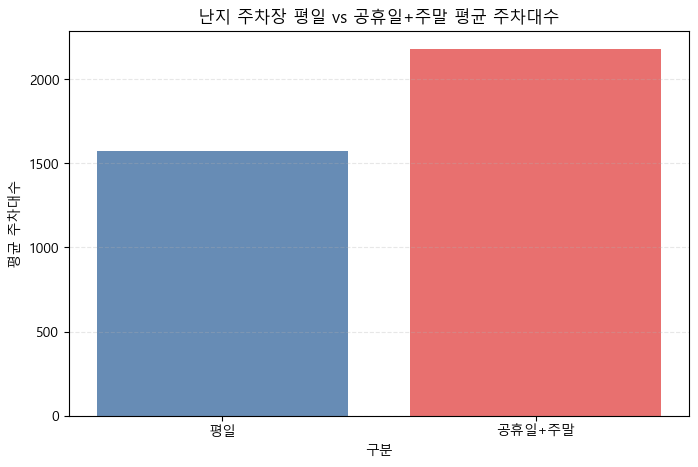

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(
    holiday_summary.index,
    holiday_summary['평균'],
    color=['#4C78A8', '#E45756'],
    alpha=0.85
)
plt.title('난지 주차장 평일 vs 공휴일+주말 평균 주차대수')
plt.xlabel('구분')
plt.ylabel('평균 주차대수')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [19]:
yearly_holiday = (
    holiday_daily.groupby(['연도', '휴일구분'])['주차대수']
    .mean()
    .reset_index()
)

yearly_holiday

,연도,휴일구분,주차대수
0,2022,공휴일+주말,2425.775862
1,2022,평일,1489.650407
2,2023,공휴일+주말,2125.147826
3,2023,평일,1531.766129
4,2024,공휴일+주말,2161.059322
5,2024,평일,1589.817814
6,2025,공휴일+주말,2016.074380
7,2025,평일,1693.508197


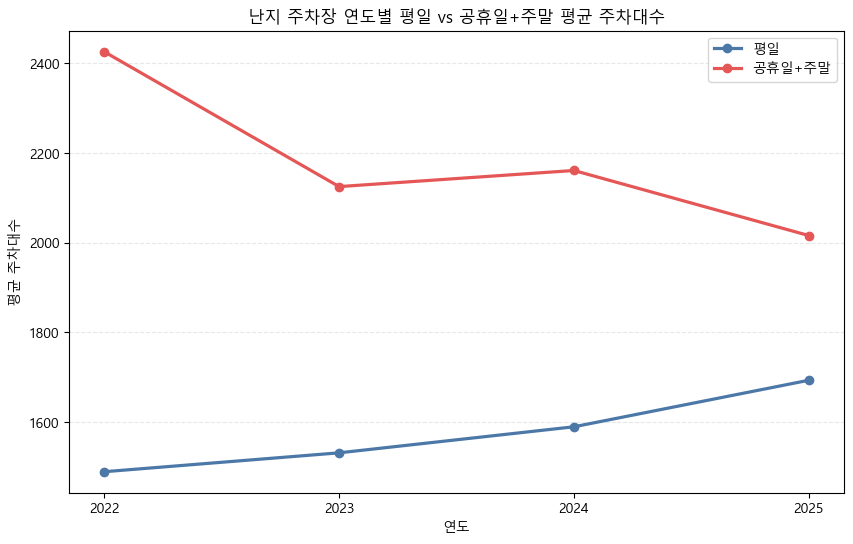

In [20]:
plt.figure(figsize=(10, 6))

for label, color in zip(['평일', '공휴일+주말'], ['#4C78A8', '#E45756']):
    temp = yearly_holiday[yearly_holiday['휴일구분'] == label].sort_values('연도')
    plt.plot(
        temp['연도'].astype(str),
        temp['주차대수'],
        marker='o',
        linewidth=2.3,
        color=color,
        label=label
    )

plt.title('난지 주차장 연도별 평일 vs 공휴일+주말 평균 주차대수')
plt.xlabel('연도')
plt.ylabel('평균 주차대수')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

In [21]:
holiday_mean = holiday_summary['평균']
print(f'공휴일+주말 평균 주차대수: {holiday_mean["공휴일+주말"]:,.1f}')
print(f'평일 평균 주차대수: {holiday_mean["평일"]:,.1f}')
print(f'공휴일+주말/평일 배수: {holiday_mean["공휴일+주말"] / holiday_mean["평일"]:.2f}배')

공휴일+주말 평균 주차대수: 2,180.3
평일 평균 주차대수: 1,575.9
공휴일+주말/평일 배수: 1.38배
